In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os

data = pd.read_csv("updated_car_data.csv")

data.head()

,Brand,Parent,Country,Luxury
0,Acura,Honda Motor Company,Japan,Yes
1,Alfa Romeo,Stellantis,Italy,Yes
2,Audi,Volkswagen Group,Germany,Yes
3,BMW,BMW Group,Germany,Yes
4,Bentley,Volkswagen Group,UK,Yes


In [3]:
# Bipartite Graph
B = nx.Graph()

for i in range(len(data)):
    parent = data.loc[i, "Parent"]
    brand = data.loc[i, "Brand"]
    country = data.loc[i, "Country"]
    luxury = data.loc[i, "Luxury"]

    B.add_node(parent, node_type="parent")
    B.add_node(brand, node_type="brand", country=country, luxury=luxury)
    B.add_edge(parent, brand)

print("Bipartite nodes:", B.number_of_nodes())
print("Bipartite edges:", B.number_of_edges())

Bipartite nodes: 72
Bipartite edges: 54


In [4]:
# separate parent nodes and brand nodes
parent_nodes = []
brand_nodes = []

for node, info in B.nodes(data=True):
    if info["node_type"] == "parent":
        parent_nodes.append(node)
    else:
        brand_nodes.append(node)

print("Parent companies:", len(parent_nodes))
print("Brands:", len(brand_nodes))

Parent companies: 18
Brands: 54


In [5]:
# Projected Brand Graph
G = nx.bipartite.projected_graph(B, brand_nodes)

print("Projected nodes:", G.number_of_nodes())
print("Projected edges:", G.number_of_edges())
print("Projected components:", nx.number_connected_components(G))

Projected nodes: 54
Projected edges: 90
Projected components: 18


Q1: How do car brands cluster? 

In [6]:
components = list(nx.connected_components(G))

print("Number of brand clusters/components:", len(components))

count = 1
for group in components:
    print("Cluster", count, ":", list(group))
    count = count + 1

Number of brand clusters/components: 18
Cluster 1 : ['Acura', 'Honda']
Cluster 2 : ['Dodge', 'Fiat', 'Jeep', 'Maserati', 'Alfa Romeo', 'Chrysler', 'RAM']
Cluster 3 : ['Audi', 'Volkswagen', 'Bugatti', 'Lamborghini', 'Porsche', 'Bentley']
Cluster 4 : ['Rolls-Royce', 'BMW', 'Mini', 'Alpina']
Cluster 5 : ['Buick', 'Saturn', 'GMC', 'Cadillac', 'Chevrolet Corvette', 'Chevrolet', 'Pontiac']
Cluster 6 : ['Lincoln', 'Ford Mustang', 'Ford', 'Mercury', 'Mer']
Cluster 7 : ['Hyundai', 'Genesis', 'Kia', 'Ioniq']
Cluster 8 : ['Range Rover', 'Land Rover', 'Jaguar']
Cluster 9 : ['Renault', 'Infiniti', 'Nissan']
Cluster 10 : ['Lexus', 'Toyota']
Cluster 11 : ['Mazda']
Cluster 12 : ['Isuzu', 'Mitsubishi']
Cluster 13 : ['Subaru']
Cluster 14 : ['Tesla']
Cluster 15 : ['Mercedes-Benz', 'Maybach']
Cluster 16 : ['Lotus', 'Volvo ']
Cluster 17 : ['Ferrari ']
Cluster 18 : ['Suzuki']


In [7]:
cluster_rows = []

for i in range(len(components)):
    group = list(components[i])
    cluster_rows.append({
        "Cluster": i + 1,
        "Size": len(group),
        "Brands": ", ".join(group)
    })

cluster_table = pd.DataFrame(cluster_rows)
cluster_table = cluster_table.sort_values(by="Size", ascending=False)
cluster_table

,Cluster,Size,Brands
4,5,7,"Buick, Saturn, GMC, Cadillac, Chevrolet Corvet..."
1,2,7,"Dodge, Fiat, Jeep, Maserati, Alfa Romeo, Chrys..."
2,3,6,"Audi, Volkswagen, Bugatti, Lamborghini, Porsch..."
5,6,5,"Lincoln, Ford Mustang, Ford, Mercury, Mer"
3,4,4,"Rolls-Royce, BMW, Mini, Alpina"
6,7,4,"Hyundai, Genesis, Kia, Ioniq"
7,8,3,"Range Rover, Land Rover, Jaguar"
8,9,3,"Renault, Infiniti, Nissan"
0,1,2,"Acura, Honda"
14,15,2,"Mercedes-Benz, Maybach"


Q2: Which parent companies are hubs?

In [8]:
parent_degree = {}

for parent in parent_nodes:
    parent_degree[parent] = B.degree(parent)

sorted_parents = sorted(parent_degree.items(), key=lambda x: x[1], reverse=True)
parent_table = pd.DataFrame(sorted_parents, columns=["Parent", "Degree"])

parent_table

,Parent,Degree
0,Stellantis,7
1,General Motors,7
2,Volkswagen Group,6
3,Ford Motor Company,5
4,BMW Group,4
5,Hyundai Motor Group,4
6,Tata Motors,3
7,Nissan Motor Company,3
8,Honda Motor Company,2
9,Toyota Motor Corporation,2


In [9]:
max_parent = max(parent_degree, key=parent_degree.get)

print("Largest parent company:", max_parent)
print("Number of brands owned:", parent_degree[max_parent])

Largest parent company: Stellantis
Number of brands owned: 7


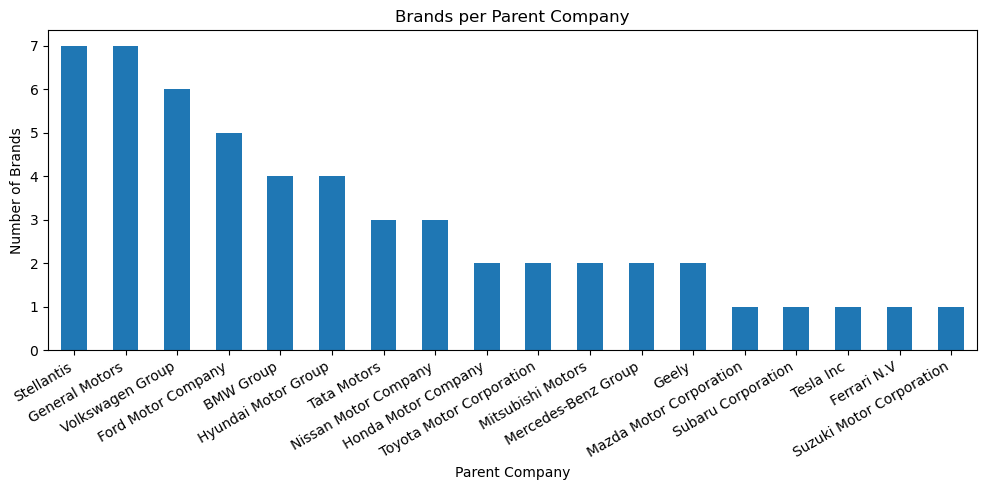

In [10]:
parent_table.plot(x="Parent", y="Degree", kind="bar", legend=False, figsize=(10,5))

plt.title("Brands per Parent Company")
plt.xlabel("Parent Company")
plt.ylabel("Number of Brands")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [11]:
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
clustering = nx.clustering(G)

results = pd.DataFrame({
    "Brand": list(G.nodes()),
    "Degree Centrality": [degree_centrality[brand] for brand in G.nodes()],
    "Betweenness Centrality": [betweenness[brand] for brand in G.nodes()],
    "Clustering Coefficient": [clustering[brand] for brand in G.nodes()]
})

results = results.sort_values(by="Degree Centrality", ascending=False)
results = results.round(3)

results

,Brand,Degree Centrality,Betweenness Centrality,Clustering Coefficient
48,Chevrolet Corvette,0.113,0.0,1.0
9,Chrysler,0.113,0.0,1.0
50,Pontiac,0.113,0.0,1.0
31,RAM,0.113,0.0,1.0
19,Jeep,0.113,0.0,1.0
52,Saturn,0.113,0.0,1.0
13,GMC,0.113,0.0,1.0
11,Fiat,0.113,0.0,1.0
10,Dodge,0.113,0.0,1.0
24,Maserati,0.113,0.0,1.0


In [12]:
print("Average clustering:", nx.average_clustering(G))

Average clustering: 0.7222222222222222


Q3: Do brands connect based on country or ownership?

In [13]:
country_counts = data["Country"].value_counts()
country_counts

Country
US             17
Japan          11
Germany         7
UK              7
Italy           5
South Korea     4
France          2
Sweden          1
Name: count, dtype: int64

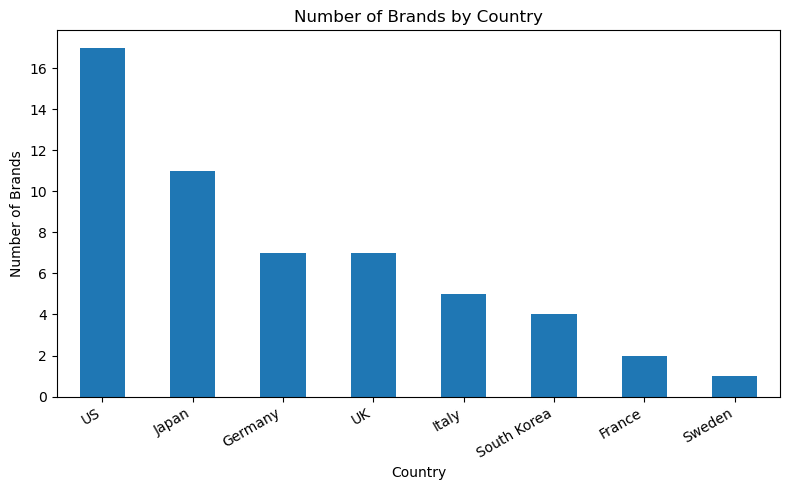

In [14]:
country_counts.plot(kind="bar", figsize=(8,5))

plt.title("Number of Brands by Country")
plt.xlabel("Country")
plt.ylabel("Number of Brands")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [15]:
country_assortativity = nx.attribute_assortativity_coefficient(G, "country")
print("Country assortativity:", country_assortativity)

Country assortativity: 0.5216049382716048


Q4: Do luxury brands form distinct patterns?

In [16]:
luxury_counts = data["Luxury"].value_counts()
luxury_counts

Luxury
No     29
Yes    25
Name: count, dtype: int64

In [17]:
luxury_data = data[data["Luxury"] == "Yes"]
luxury_data[["Brand", "Parent", "Country"]]

,Brand,Parent,Country
0,Acura,Honda Motor Company,Japan
1,Alfa Romeo,Stellantis,Italy
2,Audi,Volkswagen Group,Germany
3,BMW,BMW Group,Germany
4,Bentley,Volkswagen Group,UK
5,Bugatti,Volkswagen Group,France
7,Cadillac,General Motors,US
14,Genesis,Hyundai Motor Group,South Korea
17,Jaguar,Tata Motors,UK
18,Infiniti,Nissan Motor Company,Japan


In [18]:
luxury_by_parent = luxury_data["Parent"].value_counts()
luxury_by_parent

Parent
Volkswagen Group            5
BMW Group                   3
Tata Motors                 3
Stellantis                  2
General Motors              2
Mercedes-Benz Group         2
Honda Motor Company         1
Hyundai Motor Group         1
Nissan Motor Company        1
Toyota Motor Corporation    1
Ford Motor Company          1
Tesla Inc                   1
Geely                       1
Ferrari N.V                 1
Name: count, dtype: int64

In [19]:
luxury_assortativity = nx.attribute_assortativity_coefficient(G, "luxury")
print("Luxury assortativity:", luxury_assortativity)

Luxury assortativity: 0.09502262443438929


What happens when a major parent is removed?

In [20]:
# useing the largest parent company found earlier
major_parent = max_parent
major_parent_brands = data[data["Parent"] == major_parent]["Brand"].tolist()

print("Parent removed:", major_parent)
print("Brands removed:", major_parent_brands)
print("Number of brands removed:", len(major_parent_brands))

Parent removed: Stellantis
Brands removed: ['Alfa Romeo', 'Chrysler', 'Dodge', 'Fiat', 'Jeep', 'Maserati', 'RAM']
Number of brands removed: 7


In [21]:
G_removed = G.copy()
G_removed.remove_nodes_from(major_parent_brands)

print("Original nodes:", G.number_of_nodes())
print("After removal nodes:", G_removed.number_of_nodes())
print()

print("Original edges:", G.number_of_edges())
print("After removal edges:", G_removed.number_of_edges())
print()

print("Original components:", nx.number_connected_components(G))
print("After removal components:", nx.number_connected_components(G_removed))

Original nodes: 54
After removal nodes: 47

Original edges: 90
After removal edges: 69

Original components: 18
After removal components: 17


In [22]:
# This checks what would happen in the bipartite graph if the parent company node itself was removed.
# Brands owned by that parent become isolated because their ownership connection is gone.

B_parent_removed = B.copy()
B_parent_removed.remove_node(major_parent)

isolated_brands = []

for brand in major_parent_brands:
    if brand in B_parent_removed.nodes() and B_parent_removed.degree(brand) == 0:
        isolated_brands.append(brand)

print("Brands that become isolated after removing", major_parent, ":")
print(isolated_brands)
print("Number of isolated brands:", len(isolated_brands))

Brands that become isolated after removing Stellantis :
['Alfa Romeo', 'Chrysler', 'Dodge', 'Fiat', 'Jeep', 'Maserati', 'RAM']
Number of isolated brands: 7
